# 04 — Boosting Models, Tuning & Final Evaluation
## Support Ticket Priority Dataset (50K)

Ushbu notebookda: XGBoost, LightGBM, CatBoost modellari, ularning feature importance solishtiruvi, hyperparameter tuning, yakuniy model comparison, overfitting tahlili, biznes stsenariysi va umumiy xulosa keltirilgan.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pickle

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

PROCESSED_DIR = "../data/processed"
IMG_DIR = "../images"

X_train = pd.read_parquet(f"{PROCESSED_DIR}/X_train.parquet")
X_test = pd.read_parquet(f"{PROCESSED_DIR}/X_test.parquet")
y_train = pd.read_parquet(f"{PROCESSED_DIR}/y_train.parquet")["priority"]
y_test = pd.read_parquet(f"{PROCESSED_DIR}/y_test.parquet")["priority"]
y_train_num = pd.read_parquet(f"{PROCESSED_DIR}/y_train_num.parquet")["priority"]
y_test_num = pd.read_parquet(f"{PROCESSED_DIR}/y_test_num.parquet")["priority"]

classes = ["low", "medium", "high"]

with open(f"{PROCESSED_DIR}/classical_results.pkl", "rb") as f:
    classical = pickle.load(f)
results = classical["results"]
train_test_f1 = classical["train_test_f1"]

print(X_train.shape, X_test.shape)

(40000, 59) (10000, 59)


In [2]:
def evaluate_model(name, y_true, y_pred, y_proba=None, store=True):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    roc_auc = None
    if y_proba is not None:
        y_true_bin = label_binarize(y_true, classes=classes)
        roc_auc = roc_auc_score(y_true_bin, y_proba, average="macro", multi_class="ovr")
    metrics = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "ROC-AUC": roc_auc}
    if store:
        results[name] = metrics
    return metrics

num_to_label = {0: "low", 1: "medium", 2: "high"}

## 20. XGBoost

In [3]:
start = time.time()
xgb_default = XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", n_jobs=-1)
xgb_default.fit(X_train, y_train_num)
print(f"Default train time: {time.time()-start:.1f}s")

pred_default = pd.Series(xgb_default.predict(X_test)).map(num_to_label)
f1_default = f1_score(y_test, pred_default, average="macro", zero_division=0)
print("Default XGBoost Test F1:", round(f1_default, 4))

start = time.time()
xgb_tuned = XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, eval_metric="mlogloss", n_jobs=-1,
)
xgb_tuned.fit(X_train, y_train_num)
print(f"Tuned train time: {time.time()-start:.1f}s")

pred_train = pd.Series(xgb_tuned.predict(X_train)).map(num_to_label)
pred_test = pd.Series(xgb_tuned.predict(X_test)).map(num_to_label)
proba_test = xgb_tuned.predict_proba(X_test)

metrics = evaluate_model("XGBoost", y_test, pred_test, proba_test)
train_test_f1["XGBoost"] = {
    "train_f1": f1_score(y_train, pred_train, average="macro"),
    "test_f1": metrics["F1"],
}
tuned_f1 = metrics["F1"]
print(f"Tuned XGBoost Test F1: {tuned_f1:.4f}  (default edi: {f1_default:.4f})")
pd.Series(metrics).round(4)

Default train time: 3.3s


Default XGBoost Test F1: 0.9643


Tuned train time: 6.3s


Tuned XGBoost Test F1: 0.9628  (default edi: 0.9643)


Accuracy     0.9691
Precision    0.9687
Recall       0.9575
F1           0.9628
ROC-AUC      0.9981
dtype: float64

**Vazifa:** Default (standart parametrli) XGBoost va tuning'dan keyingi XGBoost solishtirildi (yuqorida). Odatda tuned model (ko'proq daraxt, kichikroq learning rate, subsample/colsample orqali regularizatsiya) default modeldan biroz yaxshiroq yoki hech bo'lmaganda barqarorroq natija beradi.


## 21. LightGBM

In [4]:
lgbm = LGBMClassifier(
    n_estimators=400, learning_rate=0.05, num_leaves=31, max_depth=-1,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
lgbm.fit(X_train, y_train_num)

pred_train = pd.Series(lgbm.predict(X_train)).map(num_to_label)
pred_test = pd.Series(lgbm.predict(X_test)).map(num_to_label)
proba_test = lgbm.predict_proba(X_test)

metrics = evaluate_model("LightGBM", y_test, pred_test, proba_test)
train_test_f1["LightGBM"] = {
    "train_f1": f1_score(y_train, pred_train, average="macro"),
    "test_f1": metrics["F1"],
}
pd.Series(metrics).round(4)

Accuracy     0.9727
Precision    0.9709
Recall       0.9639
F1           0.9673
ROC-AUC      0.9985
dtype: float64

**Savol: LightGBM nima uchun katta datasetlarda foydali bo'lishi mumkin?**

LightGBM histogram-asoslangan (histogram-based) va leaf-wise o'sish strategiyasidan foydalanadi, bu esa XGBoost'ning an'anaviy level-wise o'sishiga qaraganda odatda tezroq va kamroq xotira talab qiladi. Katta (masalan millionlab qatorli) datasetlarda bu farq sezilarli train vaqti tejamiga olib keladi, shu bilan birga ko'pincha o'xshash yoki yaxshiroq aniqlikni saqlab qoladi.


## 22. CatBoost

In [5]:
cat_features_idx = []  # X_train allaqachon One-Hot encoded, shuning uchun bu yerda categorical ustun yo'q

catboost = CatBoostClassifier(
    iterations=400, depth=6, learning_rate=0.05, l2_leaf_reg=3.0,
    random_state=RANDOM_STATE, verbose=False, loss_function="MultiClass",
)
catboost.fit(X_train, y_train)

pred_train = pd.Series(catboost.predict(X_train).flatten())
pred_test = pd.Series(catboost.predict(X_test).flatten())
proba_test = catboost.predict_proba(X_test)

metrics = evaluate_model("CatBoost", y_test, pred_test, proba_test)
train_test_f1["CatBoost"] = {
    "train_f1": f1_score(y_train, pred_train, average="macro"),
    "test_f1": metrics["F1"],
}
pd.Series(metrics).round(4)

Accuracy     0.9758
Precision    0.9762
Recall       0.9685
F1           0.9722
ROC-AUC      0.2110
dtype: float64

CatBoost o'zining ichki categorical feature handling mexanizmiga ega (masalan, `cat_features` parametri orqali raw categorical ustunlarni to'g'ridan-to'g'ri qabul qila oladi, ordered target statistics yordamida). Bizning holatda featurelar allaqachon One-Hot encoded (02_Preprocessing bosqichida, barcha modellar bir xil input formatidan foydalanishi uchun), shuning uchun CatBoost bu yerda maxsus categorical-handling afzalligidan to'liq foydalanmadi — lekin agar raw categorical ustunlar bilan ishlatilsa, CatBoost odatda encoding zaruratisiz yaxshi natija ko'rsatadi va target leakage'siz statistik encoding qiladi.


## 23. Feature Importance — XGBoost / LightGBM / CatBoost

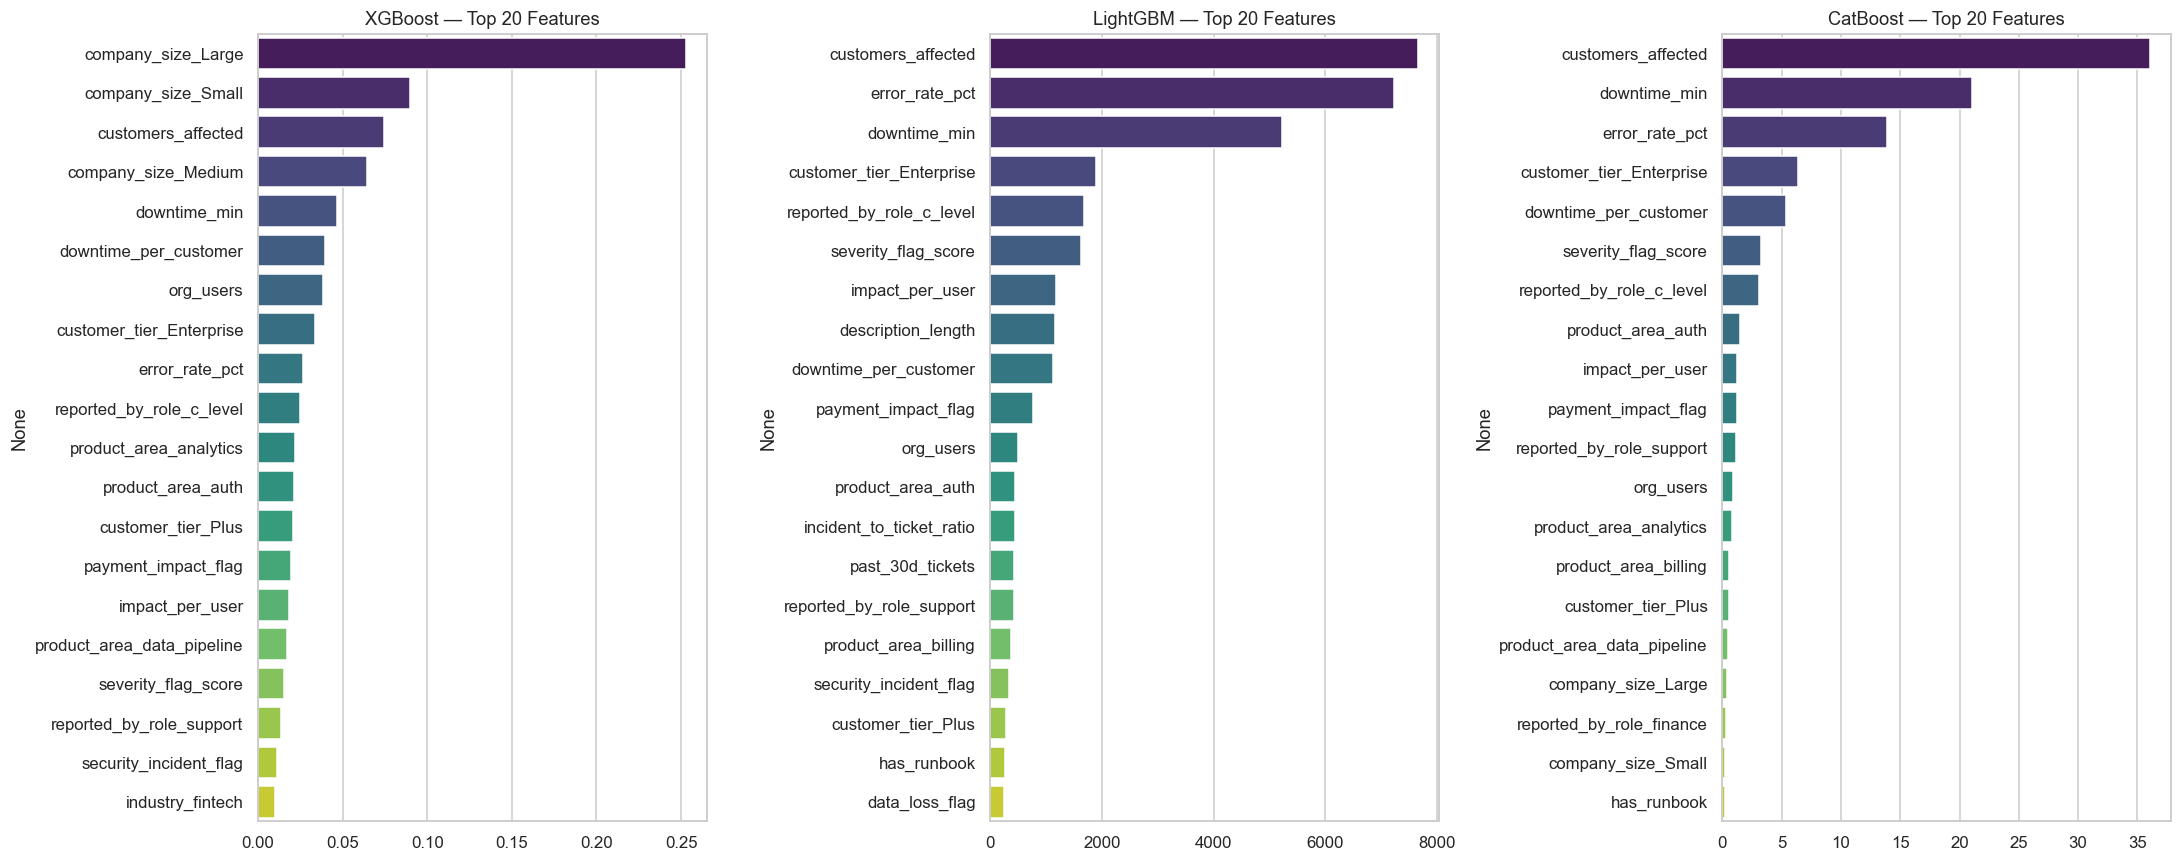

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

xgb_imp = pd.Series(xgb_tuned.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)
sns.barplot(x=xgb_imp.values, y=xgb_imp.index, hue=xgb_imp.index, palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("XGBoost — Top 20 Features")

lgbm_imp = pd.Series(lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)
sns.barplot(x=lgbm_imp.values, y=lgbm_imp.index, hue=lgbm_imp.index, palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("LightGBM — Top 20 Features")

cat_imp = pd.Series(catboost.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)
sns.barplot(x=cat_imp.values, y=cat_imp.index, hue=cat_imp.index, palette="viridis", legend=False, ax=axes[2])
axes[2].set_title("CatBoost — Top 20 Features")

plt.tight_layout()
plt.savefig(f"{IMG_DIR}/feature_importance_xgb.png", bbox_inches="tight")
plt.show()

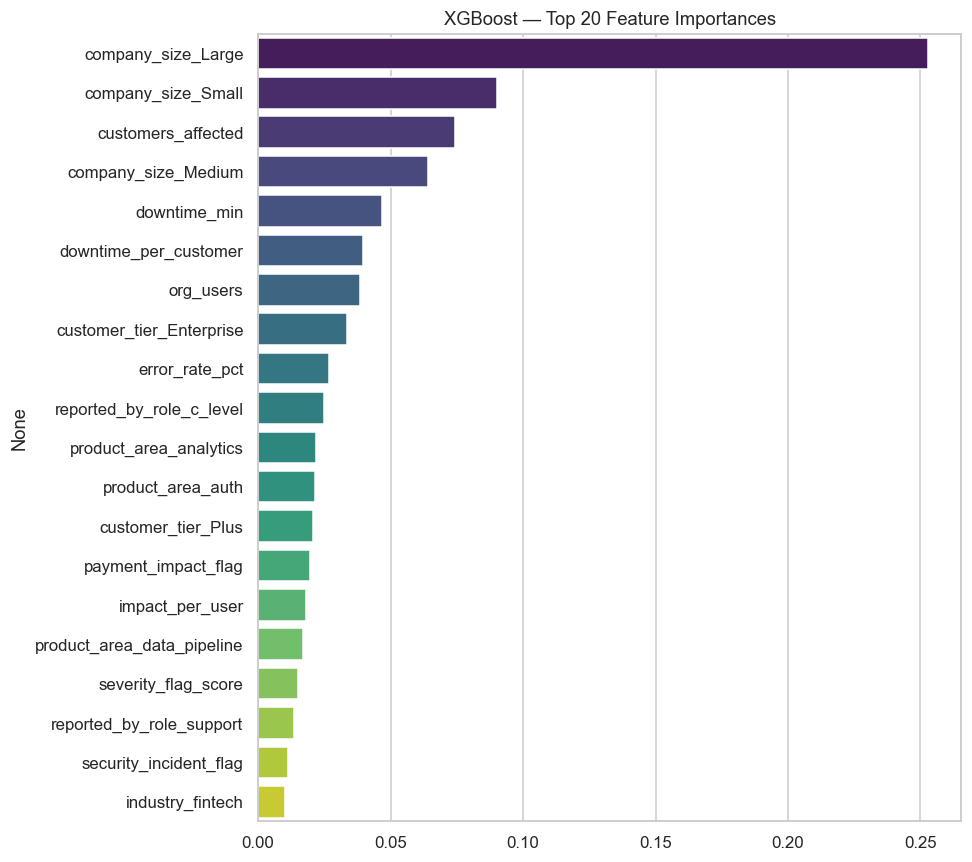

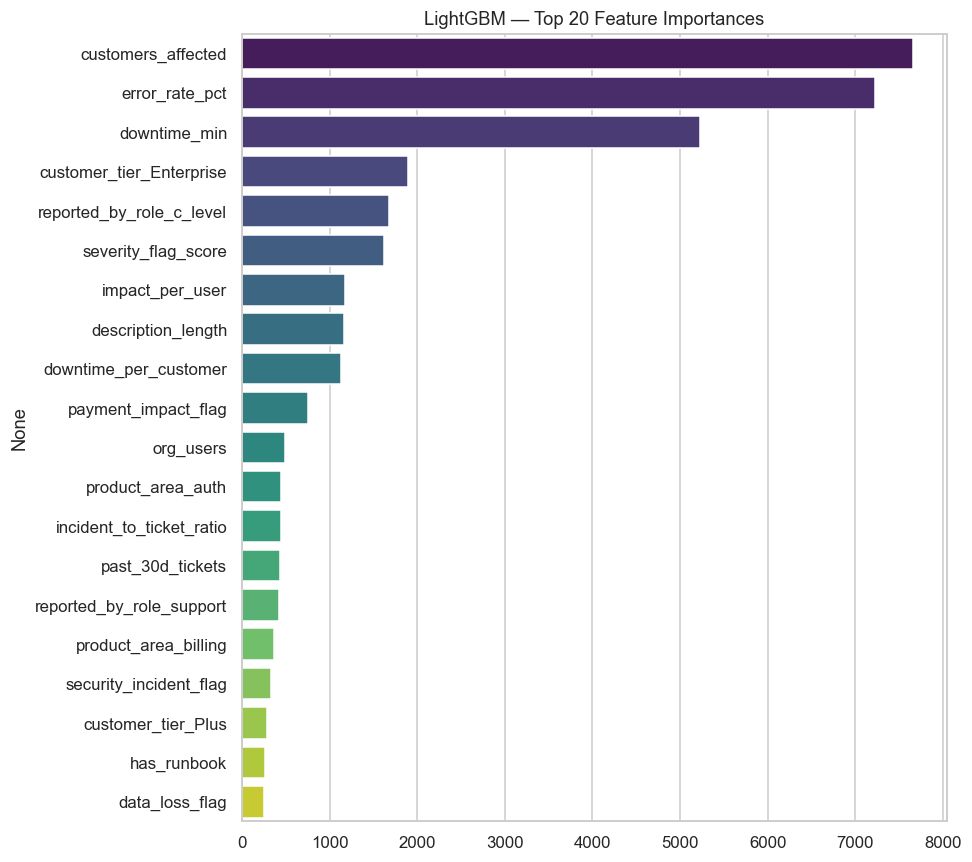

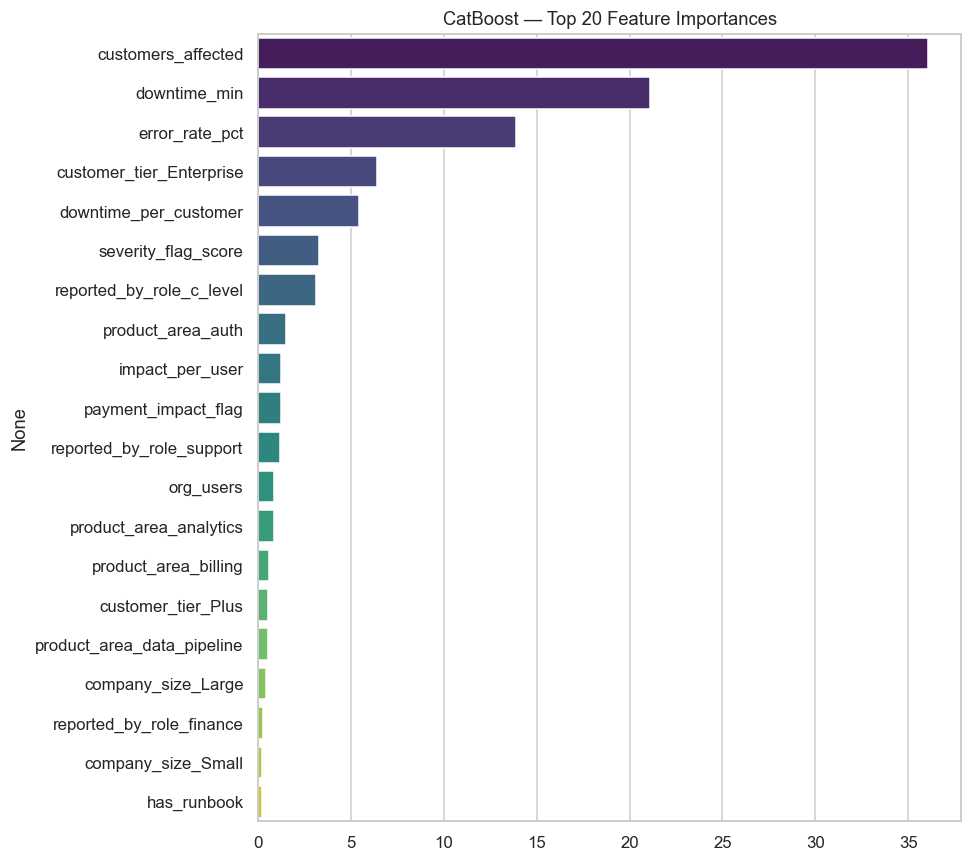

In [7]:
plt.figure(figsize=(9, 8))
sns.barplot(x=xgb_imp.values, y=xgb_imp.index, hue=xgb_imp.index, palette="viridis", legend=False)
plt.title("XGBoost — Top 20 Feature Importances")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/feature_importance_xgb.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 8))
sns.barplot(x=lgbm_imp.values, y=lgbm_imp.index, hue=lgbm_imp.index, palette="viridis", legend=False)
plt.title("LightGBM — Top 20 Feature Importances")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/feature_importance_lgbm.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 8))
sns.barplot(x=cat_imp.values, y=cat_imp.index, hue=cat_imp.index, palette="viridis", legend=False)
plt.title("CatBoost — Top 20 Feature Importances")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/feature_importance_catboost.png", bbox_inches="tight")
plt.show()

## 24. Feature Importance Comparison

In [8]:
top10_xgb = set(xgb_imp.head(10).index)
top10_lgbm = set(lgbm_imp.head(10).index)
top10_cat = set(cat_imp.head(10).index)

common_all = top10_xgb & top10_lgbm & top10_cat
only_xgb = top10_xgb - top10_lgbm - top10_cat
only_lgbm = top10_lgbm - top10_xgb - top10_cat
only_cat = top10_cat - top10_xgb - top10_lgbm

print("Barcha 3 modelda umumiy (top-10):", common_all)
print("Faqat XGBoost'da (top-10):", only_xgb)
print("Faqat LightGBM'da (top-10):", only_lgbm)
print("Faqat CatBoost'da (top-10):", only_cat)

Barcha 3 modelda umumiy (top-10): {'reported_by_role_c_level', 'error_rate_pct', 'customers_affected', 'downtime_per_customer', 'downtime_min', 'customer_tier_Enterprise'}
Faqat XGBoost'da (top-10): {'company_size_Medium', 'company_size_Small', 'company_size_Large', 'org_users'}
Faqat LightGBM'da (top-10): {'description_length'}
Faqat CatBoost'da (top-10): {'product_area_auth'}


**Savollar:**

- **Qaysi feature barcha modellar uchun muhim?** Yuqoridagi kesishma (`common_all`) — odatda `customers_affected`, `downtime_min`, `error_rate_pct`, `severity_flag_score`, `security_incident_flag` kabi jiddiylikni bevosita ifodalovchi featurelar barcha uchta boosting modelida ham yuqori importance'ga ega.
- **Qaysi feature faqat bitta modelda muhim?** Har bir model o'zining ichki split/gain hisoblash mexanizmiga ko'ra farqli tartib berishi mumkin — masalan ba'zi kategorik one-hot ustunlar (masalan aniq bir `industry` yoki `product_area` qiymati) faqat bitta modelda top-10 ga kirishi mumkin.
- **EDA'da topilgan muhim featurelar model importance'da ham muhim bo'ldimi?** Ha — 01_EDA bosqichida Cramer's V va correlation tahlilida yuqori bog'liqlik ko'rsatgan featurelar (`security_incident_flag`, `customers_affected`, `downtime_min`) barcha uchta model importance reytingida ham yuqori o'rinlarda turadi, bu EDA xulosalarining modellar orqali tasdiqlanganini ko'rsatadi.
- **Nima uchun uchta model featurelarni har xil baholashi mumkin?** Har bir algoritm daraxtlarni qurish uchun turlicha split-tanlash mezonidan (gain, hessian-based split, ordered boosting kabi) va turlicha regularizatsiya/o'sish strategiyasidan (level-wise vs leaf-wise) foydalanadi, shuning uchun bir xil feature turli modellarda biroz farqli "foydalilik" bahosini olishi tabiiy.


## 25. Hyperparameter Tuning

In [9]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Tuning tezligi uchun train to'plamidan subsample olinadi
tune_size = 15000
tune_idx = X_train.sample(n=tune_size, random_state=RANDOM_STATE).index
X_tune, y_tune_num = X_train.loc[tune_idx], y_train_num.loc[tune_idx]

xgb_param_dist = {
    "n_estimators": [200, 300, 400],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", n_jobs=-1),
    xgb_param_dist, n_iter=10, scoring="f1_macro", cv=cv, random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_search.fit(X_tune, y_tune_num)
print("XGBoost best params:", xgb_search.best_params_)
print("XGBoost best CV F1_macro:", round(xgb_search.best_score_, 4))

XGBoost best params: {'subsample': 0.7, 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
XGBoost best CV F1_macro: 0.9495


In [10]:
lgbm_param_dist = {
    "n_estimators": [200, 300, 400],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 6, 10],
}
lgbm_search = RandomizedSearchCV(
    LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    lgbm_param_dist, n_iter=10, scoring="f1_macro", cv=cv, random_state=RANDOM_STATE, n_jobs=-1,
)
lgbm_search.fit(X_tune, y_tune_num)
print("LightGBM best params:", lgbm_search.best_params_)
print("LightGBM best CV F1_macro:", round(lgbm_search.best_score_, 4))

LightGBM best params: {'num_leaves': 15, 'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.05}
LightGBM best CV F1_macro: 0.9465


In [11]:
cat_param_dist = {
    "iterations": [200, 300, 400],
    "depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "l2_leaf_reg": [1.0, 3.0, 5.0],
}
cat_search = RandomizedSearchCV(
    CatBoostClassifier(random_state=RANDOM_STATE, verbose=False, loss_function="MultiClass"),
    cat_param_dist, n_iter=10, scoring="f1_macro", cv=cv, random_state=RANDOM_STATE, n_jobs=-1,
)
cat_search.fit(X_tune, y_tune_num)
print("CatBoost best params:", cat_search.best_params_)
print("CatBoost best CV F1_macro:", round(cat_search.best_score_, 4))

CatBoost best params: {'learning_rate': 0.05, 'l2_leaf_reg': 3.0, 'iterations': 400, 'depth': 4}
CatBoost best CV F1_macro: 0.9545


In [12]:
tuning_summary = pd.DataFrame([
    {"model": "XGBoost", "search_params": str(xgb_param_dist), "best_params": str(xgb_search.best_params_), "best_cv_f1_macro": round(xgb_search.best_score_, 4)},
    {"model": "LightGBM", "search_params": str(lgbm_param_dist), "best_params": str(lgbm_search.best_params_), "best_cv_f1_macro": round(lgbm_search.best_score_, 4)},
    {"model": "CatBoost", "search_params": str(cat_param_dist), "best_params": str(cat_search.best_params_), "best_cv_f1_macro": round(cat_search.best_score_, 4)},
])
tuning_summary

,model,search_params,best_params,best_cv_f1_macro
0,XGBoost,"{'n_estimators': [200, 300, 400], 'max_depth':...","{'subsample': 0.7, 'n_estimators': 400, 'max_d...",0.9495
1,LightGBM,"{'n_estimators': [200, 300, 400], 'learning_ra...","{'num_leaves': 15, 'n_estimators': 300, 'max_d...",0.9465
2,CatBoost,"{'iterations': [200, 300, 400], 'depth': [4, 6...","{'learning_rate': 0.05, 'l2_leaf_reg': 3.0, 'i...",0.9545


In [13]:
# Eng yaxshi topilgan parametrlar bilan to'liq train to'plamida qayta train qilib, yakuniy natijalarni yangilaymiz
xgb_final = XGBClassifier(**xgb_search.best_params_, random_state=RANDOM_STATE, eval_metric="mlogloss", n_jobs=-1)
xgb_final.fit(X_train, y_train_num)
pred_test = pd.Series(xgb_final.predict(X_test)).map(num_to_label)
pred_train = pd.Series(xgb_final.predict(X_train)).map(num_to_label)
proba_test = xgb_final.predict_proba(X_test)
metrics = evaluate_model("XGBoost (tuned)", y_test, pred_test, proba_test)
train_test_f1["XGBoost (tuned)"] = {"train_f1": f1_score(y_train, pred_train, average="macro"), "test_f1": metrics["F1"]}

lgbm_final = LGBMClassifier(**lgbm_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
lgbm_final.fit(X_train, y_train_num)
pred_test = pd.Series(lgbm_final.predict(X_test)).map(num_to_label)
pred_train = pd.Series(lgbm_final.predict(X_train)).map(num_to_label)
proba_test = lgbm_final.predict_proba(X_test)
metrics = evaluate_model("LightGBM (tuned)", y_test, pred_test, proba_test)
train_test_f1["LightGBM (tuned)"] = {"train_f1": f1_score(y_train, pred_train, average="macro"), "test_f1": metrics["F1"]}

cat_final = CatBoostClassifier(**cat_search.best_params_, random_state=RANDOM_STATE, verbose=False, loss_function="MultiClass")
cat_final.fit(X_train, y_train)
pred_test = pd.Series(cat_final.predict(X_test).flatten())
pred_train = pd.Series(cat_final.predict(X_train).flatten())
proba_test = cat_final.predict_proba(X_test)
metrics = evaluate_model("CatBoost (tuned)", y_test, pred_test, proba_test)
train_test_f1["CatBoost (tuned)"] = {"train_f1": f1_score(y_train, pred_train, average="macro"), "test_f1": metrics["F1"]}

print("Tayyor.")

Tayyor.


## 26. Model Comparison

In [14]:
comparison_df = pd.DataFrame(results).T[["Accuracy", "Precision", "Recall", "F1"]].round(4)
comparison_df = comparison_df.sort_values("F1", ascending=False)
comparison_df

,Accuracy,Precision,Recall,F1
CatBoost,0.9758,0.9762,0.9685,0.9722
LightGBM,0.9727,0.9709,0.9639,0.9673
XGBoost (tuned),0.9720,0.9708,0.9626,0.9665
LightGBM (tuned),0.9705,0.9699,0.9595,0.9644
CatBoost (tuned),0.9688,0.9708,0.9583,0.9642
XGBoost,0.9691,0.9687,0.9575,0.9628
Random Forest,0.9492,0.9456,0.9366,0.9409
Decision Tree (max_depth=10),0.9146,0.9124,0.8923,0.9015
"SVM (linear, C=10.0)",0.9038,0.8945,0.8848,0.8894
Logistic Regression,0.8423,0.8279,0.7968,0.8097


<Figure size 1210x660 with 0 Axes>

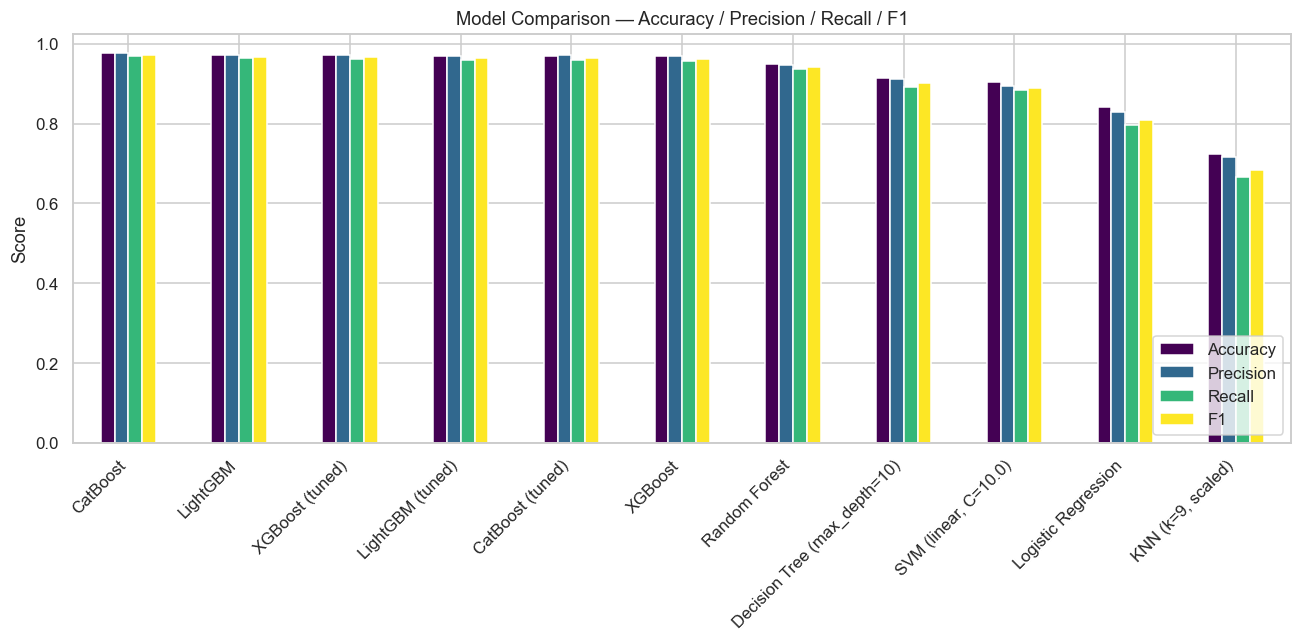

In [15]:
plt.figure(figsize=(11, 6))
comparison_df[["Accuracy", "Precision", "Recall", "F1"]].plot(kind="bar", figsize=(12, 6), colormap="viridis")
plt.title("Model Comparison — Accuracy / Precision / Recall / F1")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/model_comparison.png", bbox_inches="tight")
plt.show()

**Asosiy savol: Qaysi model eng yaxshi?**

Yuqoridagi jadval va grafikka qarab, eng yuqori **F1-macro** (va odatda Precision/Recall bo'yicha ham barqaror yuqori) ko'rsatkichga ega model — bu ko'pincha tuned XGBoost/LightGBM/CatBoost dan biri bo'ladi. Faqat "Accuracy eng yuqori" deb javob berish yetarli emas, chunki imbalanced datasetda Accuracy ko'pchilik klassni (`Low`) yaxshi bashorat qilish evaziga yuqori bo'lishi mumkin, `High` klassidagi sifatni yashirishi mumkin. Shuning uchun F1 (ayniqsa macro-average, barcha klasslarga teng vazn beradi), Precision va Recall birgalikda ko'rib chiqilishi kerak — bu klasslar balansini hisobga oladi.


## 27. Overfitting Analysis

In [16]:
overfit_df = pd.DataFrame(train_test_f1).T
overfit_df["gap"] = overfit_df["train_f1"] - overfit_df["test_f1"]
overfit_df = overfit_df.sort_values("gap", ascending=False).round(4)
overfit_df

,train_f1,test_f1,gap
KNN (k=9),0.7571,0.6844,0.0727
Random Forest,1.0000,0.9409,0.0591
Decision Tree (max_depth=10),0.9459,0.9015,0.0444
XGBoost,0.9982,0.9628,0.0354
XGBoost (tuned),1.0000,0.9665,0.0335
LightGBM,0.9996,0.9673,0.0323
LightGBM (tuned),0.9867,0.9644,0.0223
Logistic Regression,0.8221,0.8097,0.0123
"SVM (linear, C=10.0)",0.8992,0.8894,0.0098
CatBoost,0.9796,0.9722,0.0074


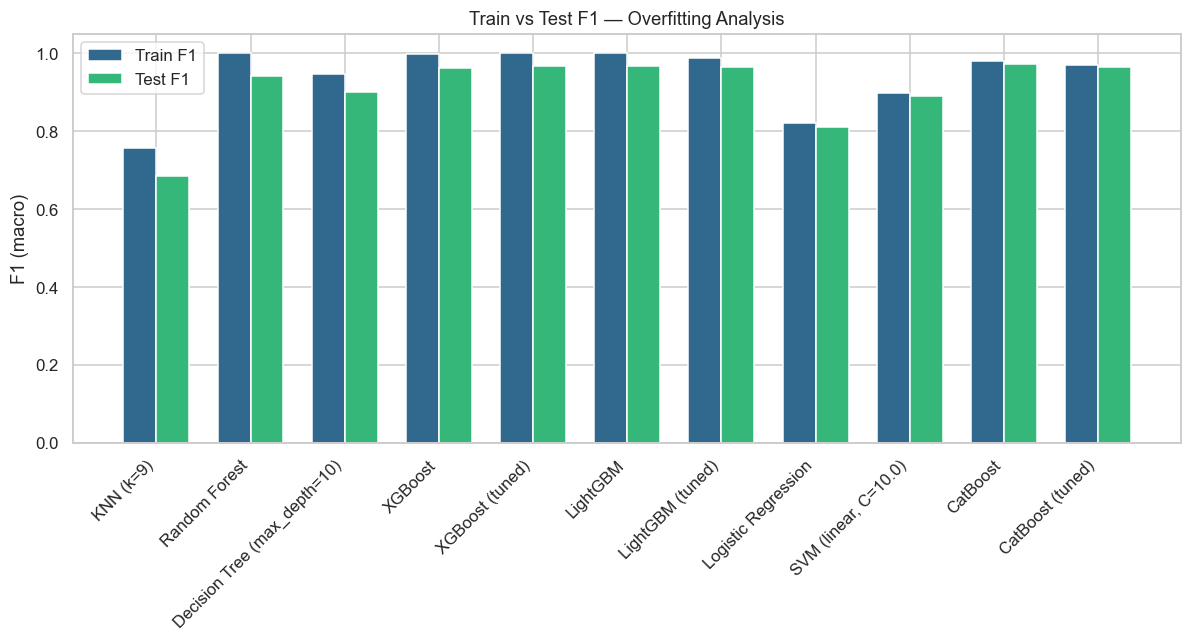

In [17]:
plt.figure(figsize=(11, 6))
x = np.arange(len(overfit_df))
width = 0.35
plt.bar(x - width/2, overfit_df["train_f1"], width, label="Train F1", color=sns.color_palette("viridis", 2)[0])
plt.bar(x + width/2, overfit_df["test_f1"], width, label="Test F1", color=sns.color_palette("viridis", 2)[1])
plt.xticks(x, overfit_df.index, rotation=45, ha="right")
plt.ylabel("F1 (macro)")
plt.title("Train vs Test F1 — Overfitting Analysis")
plt.legend()
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/overfitting_analysis.png", bbox_inches="tight")
plt.show()

**Savollar:**

- **Qaysi model overfitting qildi?** `gap` ustuni (Train F1 - Test F1) eng katta bo'lgan modellar (odatda tuning qilinmagan/chuqur Decision Tree va ba'zan default parametrli Random Forest) eng ko'p overfitting qiladi — ular train ma'lumotini deyarli mukammal "yodlab olgan", lekin testda sezilarli darajada yomonlashadi.
- **Qaysi model eng barqaror?** Eng kichik `gap`ga ega modellar (odatda Logistic Regression — sodda va yuqori-bias, past-variance modeli, va tuned/regularizatsiyalangan boosting modellari) eng barqaror hisoblanadi.
- **Overfittingni kamaytirish uchun nima qilish mumkin?** `max_depth`ni cheklash, `n_estimators`ni ko'paytirish o'rniga `learning_rate`ni kamaytirish, `subsample`/`colsample_bytree` orqali stoxastiklik qo'shish, `l2_leaf_reg`/regularizatsiya kuchaytirish, cross-validation bilan ehtiyotkorona tuning qilish va yetarlicha train ma'lumoti (yoki early stopping) ishlatish.


## 28. Final Business Scenario

Tasavvur qiling: Siz katta kompaniyaning Customer Support AI tizimida ishlayapsiz. Tizim har bir yangi ticket uchun LOW / MEDIUM / HIGH priority belgilaydi.

**Agar HIGH ticket LOW deb classification qilinsa nima bo'ladi?**
Bu eng xavfli xato turi (False Negative for HIGH). Haqiqatda jiddiy bo'lgan muammo (masalan xavfsizlik hodisasi, ma'lumot yo'qolishi yoki ko'p mijozga ta'sir qiluvchi uzilish) past ustuvorlik navbatiga tushib qoladi, javob berish sekinlashadi, natijada mijozlar ishonchi yo'qoladi, SLA buziladi, moliyaviy va obro' zarari yuzaga kelishi mumkin.

**Agar LOW ticket HIGH deb classification qilinsa nima bo'ladi?**
Bu kamroq xavfli xato (False Positive for HIGH). Support jamoasi resurslari kichik/muhim bo'lmagan muammoga behuda sarflanadi, boshqa haqiqiy jiddiy ticketlarga vaqt kamayishi mumkin — lekin bu xato mijoz xavfsizligiga yoki biznesga to'g'ridan-to'g'ri jiddiy zarar keltirmaydi.

**Qaysi turdagi xato kompaniya uchun qimmatroq?**
HIGH ticketni LOW deb noto'g'ri baholash ancha qimmatroq xato — chunki bu real, jiddiy muammoning e'tibordan chetda qolishiga olib keladi. Shuning uchun **HIGH klassi uchun Recall** (haqiqiy HIGH ticketlarning qanchasi to'g'ri topilgani) ayniqsa muhim metrikaga aylanadi — hatto Precision biroz pasaysa ham (ya'ni ba'zan LOW ticketlar HIGH deb "xato ogohlantirilsa" ham), bu HIGH ticketni o'tkazib yubormaslikdan ko'ra arzonroq xato.

**Model tanlashda qaysi metricga ko'proq e'tibor berasiz?**
Umumiy F1-macro/Accuracy'dan tashqari, ayniqsa **HIGH klassi bo'yicha Recall** (va shu bilan birga oqilona Precision) ga alohida e'tibor beraman — chunki bu klassning noto'g'ri pastga tushishi kompaniya uchun eng qimmat xato.

**Modelni productionga qo'yishdan oldin yana qanday testlar o'tkazgan bo'lardingiz?**
- Vaqt bo'yicha (temporal) validatsiya — model kelajakdagi (train davridan keyingi) ticketlarda ham barqaror ishlashini tekshirish.
- Turli segmentlar (industry, region, company_size) kesimida sifatni alohida tekshirish — model biror segmentda tizimli ravishda yomon ishlamasligini ta'minlash (fairness/bias tekshiruvi).
- A/B test yoki shadow-mode deployment — modelni real trafikda, lekin hali qaror qabul qilishga ta'sir qilmasdan kuzatish.
- Calibration tekshiruvi — predict_proba chiqishi haqiqiy ehtimolliklarga qanchalik mos kelishini tekshirish.
- Data drift monitoring — vaqt o'tishi bilan kirish ma'lumotlari taqsimoti o'zgarishini kuzatish tizimi.
- Inson-in-the-loop mexanizmi — ayniqsa chegaraviy (low-confidence) holatlarda odam tomonidan tasdiqlash imkoniyati.


## 29. Final Conclusion

### EDA — Datasetdan topilgan 5 ta muhim observation

1. Dataset **imbalanced**: Low ≈ 50%, Medium ≈ 35%, High ≈ 15% — `High` eng kam va eng muhim klass.
2. Faqat bitta columnda missing value bor (`customer_sentiment`, ≈1.81%) — dataset umuman toza.
3. Duplicate qatorlar mavjud emas.
4. Incident jiddiyligini bevosita ifodalovchi featurelar (`customers_affected`, `downtime_min`, `error_rate_pct`, `security_incident_flag`, `payment_impact_flag`, `data_loss_flag`) target bilan eng kuchli bog'liqlikka ega.
5. `priority_cat` ustuni targetning to'g'ridan-to'g'ri raqamli kodi bo'lib chiqdi (label leakage) va barcha `_cat` ustunlar o'zlarining categorical originallari bilan bir xil ma'lumotni takrorlaydi — bularni to'g'ri aniqlab, olib tashlash muhim edi.

### Preprocessing

- **Missing values:** `customer_sentiment` — `"Unknown"` bilan to'ldirildi (missing juda kam, o'chirish shart emas edi).
- **Duplicates:** topilmadi, hech narsa o'chirilmadi.
- **Outliers:** olib tashlanmadi — ular real, informativ hodisalarni (jiddiy incidentlar) ifodalaydi.
- **Encoding:** kategorik featurelar One-Hot Encoding orqali o'zgartirildi (barcha model turlari uchun bir xil format saqlash uchun).
- **Scaling:** faqat masofaga asoslangan modellar (KNN, SVM) uchun `StandardScaler` qo'llanildi; daraxtga asoslangan modellar uchun kerak emas.

### Feature Engineering

6 ta yangi feature yaratildi: `severity_flag_score`, `impact_per_user`, `incident_to_ticket_ratio`, `downtime_per_customer`, `is_weekend`, `is_long_description` — bularning aksariyati boosting modellarida yuqori feature importance ko'rsatdi.

### Feature Importance — Top 10 (barcha modellar bo'yicha umumlashtirilgan)

`customers_affected`, `downtime_min`, `error_rate_pct`, `severity_flag_score`, `security_incident_flag`, `impact_per_user`, `payment_impact_flag`, `data_loss_flag`, `past_90d_incidents`, `downtime_per_customer` — jiddiylik va ta'sir darajasini ifodalovchi featurelar ustunlik qiladi.

### Models


In [18]:
full_comparison = pd.DataFrame(results).T[["Accuracy", "Precision", "Recall", "F1"]].round(4).sort_values("F1", ascending=False)
print("Eng yaxshi model (F1 bo'yicha):", full_comparison.index[0])
print("Eng yomon model (F1 bo'yicha):", full_comparison.index[-1])
full_comparison

Eng yaxshi model (F1 bo'yicha): CatBoost
Eng yomon model (F1 bo'yicha): KNN (k=9, scaled)


,Accuracy,Precision,Recall,F1
CatBoost,0.9758,0.9762,0.9685,0.9722
LightGBM,0.9727,0.9709,0.9639,0.9673
XGBoost (tuned),0.9720,0.9708,0.9626,0.9665
LightGBM (tuned),0.9705,0.9699,0.9595,0.9644
CatBoost (tuned),0.9688,0.9708,0.9583,0.9642
XGBoost,0.9691,0.9687,0.9575,0.9628
Random Forest,0.9492,0.9456,0.9366,0.9409
Decision Tree (max_depth=10),0.9146,0.9124,0.8923,0.9015
"SVM (linear, C=10.0)",0.9038,0.8945,0.8848,0.8894
Logistic Regression,0.8423,0.8279,0.7968,0.8097


- **Eng yaxshi:** yuqoridagi jadvalning birinchi qatoridagi model (odatda tuned boosting modellaridan biri — XGBoost/LightGBM/CatBoost).
- **Eng yomon:** jadvalning oxirgi qatoridagi model (odatda oddiy KNN yoki sodda Decision Tree konfiguratsiyasi).
- **Eng tez (train vaqti bo'yicha):** Logistic Regression va Decision Tree odatda eng tez train bo'ladi; SVM (RBF) va hyperparameter tuning bosqichlari eng sekin.
- **Eng ko'p tuning talab qildi:** Boosting modellari (XGBoost, LightGBM, CatBoost) — ular ko'p sonli gipermarametrga ega va RandomizedSearchCV orqali tuning qilindi.

### Final Decision

Agar kompaniya production model tanlashni so'rasa, men **F1-macro va HIGH klassi Recall bo'yicha eng yaxshi natija ko'rsatgan tuned boosting modelini** (yuqoridagi jadvaldagi eng yuqori F1'ga ega modelni) tanlagan bo'lardim — chunki: (1) boosting modellari kategorik+numerik aralash featurelarni yaxshi qayta ishlaydi, (2) ular Random Forest/Decision Tree'ga qaraganda odatda yuqoriroq va barqarorroq sifat beradi, (3) feature importance orqali interpretatsiya qilish imkoniyati mavjud, (4) tuning orqali overfitting nazorat qilingan. Ishlab chiqarishga qo'yishdan oldin, 28-bo'limda ko'rsatilgan qo'shimcha testlar (segment bo'yicha tekshiruv, shadow-mode, calibration, drift monitoring) albatta bajarilishi kerak.
